# Experiment 1: When Does Contamination Matter?

This notebook reproduces the foundational experiment presented in the section **"When does contamination matter?"**

The objective of this section is to build a qualitative intuition for how different Bayesian inference methods react to obvious violations of their underlying statistical assumptions. Using a 6-point toy dataset containing five well-behaved observations and one extreme outlier ($x = 15$), we evaluate the posterior distributions of the population mean across five distinct models:

1. **Normal Model** 
2. **Contaminated Normal Model** 
3. **Student-t Model** 
4. **Bayesian Bootstrap** 
5. **Trimmed Bayesian Bootstrap** 

By visualizing how each model shifts its credible interval in the presence of this single contaminant, we demonstrate that simply using a Bayesian framework does not automatically guarantee robustness against outliers.

In [24]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import jax
import jax.numpy as jnp
import jax.scipy.stats as stats
import numpyro
from numpyro.infer import MCMC, NUTS, Predictive
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Import helper function from the src directory
from src.inference.runner import run_parametric_mcmc

# Import models from the src directory
from src.models import (
    normal_model,
    contaminated_normal_model,
    student_t_model,
    bayesian_bootstrap_mean,
    bayesian_bootstrap_trimmed
)

# Import the toy data from the data directory
data = jnp.load('../data/toy_dataset.npy')
print(f"Imported toy data: {data}")

Imported toy data: [-2. -1.  0.  1.  2. 15.]


## Implementation

We run MCMC and Predictive on the five different models. The model definitions can be found in `/src/models/` and the helper function in `/src/inference/runner.py`.

Note that the `num_samples=4000` and `num_warmup=1000` are arbitrarily chosen and was not explicitly mentioned by the author. 

In [ ]:
print("Running Normal Model...")
mu_normal = run_parametric_mcmc(normal_model, data)["mu"]

print("Running Contaminated Normal Model...")
samples_contaminated = run_parametric_mcmc(contaminated_normal_model, data)
mu_contaminated = samples_contaminated["mu"]

print("Running Student-t Model...")
mu_student_t = run_parametric_mcmc(student_t_model, data)["mu"]

print("Running Bayesian Bootstrap (Mean)...")
predictive_bb_mean = Predictive(bayesian_bootstrap_mean, num_samples=4000)
mu_bb_mean = predictive_bb_mean(jax.random.PRNGKey(1), data)["mu"]

print("Running Bayesian Bootstrap (Trimmed)...")
predictive_bb_trim = Predictive(bayesian_bootstrap_trimmed, num_samples=4000)
mu_bb_trim = predictive_bb_trim(jax.random.PRNGKey(2), data)["mu"]

Running Normal Model...


sample: 100%|██████████| 5000/5000 [00:00<00:00, 5644.53it/s, 3 steps of size 6.05e-01. acc. prob=0.94]


Running Contaminated Normal Model...


sample: 100%|██████████| 5000/5000 [00:01<00:00, 4255.42it/s, 7 steps of size 2.73e-01. acc. prob=0.93] 


Running Student-t Model...


sample: 100%|██████████| 5000/5000 [00:01<00:00, 4871.95it/s, 7 steps of size 5.30e-01. acc. prob=0.86] 


Running Bayesian Bootstrap (Mean)...
Running Bayesian Bootstrap (Trimmed)...


We now proceed the posterior distributions for the population mean with a violin plot.

/var/folders/mr/gyhq4nd5159cfdvmmd1l_d440000gn/T/ipykernel_3969/389645087.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


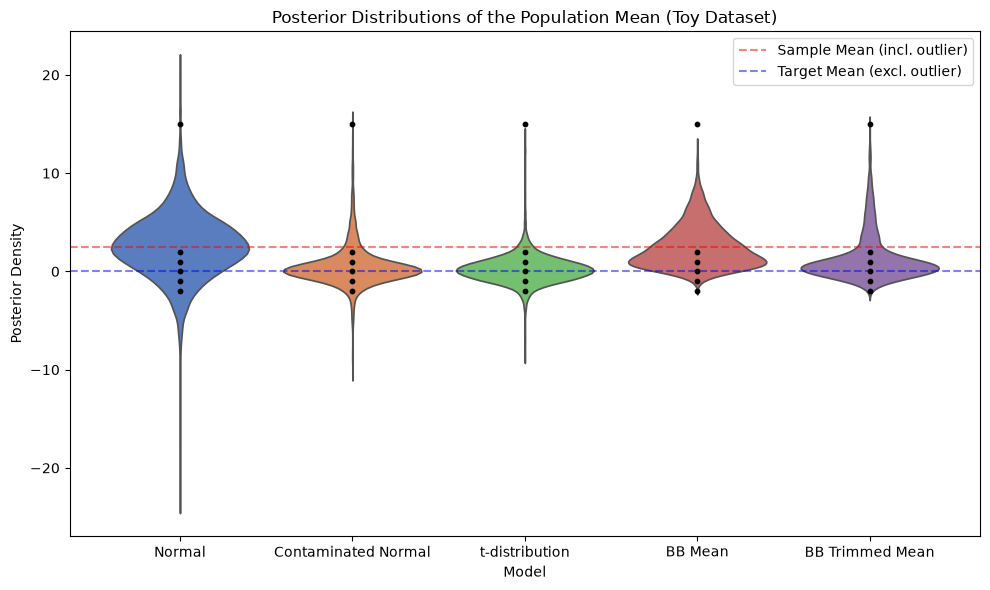

In [20]:
# Combine all samples into a Pandas DataFrame for easy plotting with Seaborn
df = pd.DataFrame({
    "Normal": mu_normal,
    "Contaminated Normal": mu_contaminated,
    "t-distribution": mu_student_t,
    "BB Mean": mu_bb_mean,
    "BB Trimmed Mean": mu_bb_trim
})

# Melt the dataframe for Seaborn
df_melted = df.melt(var_name="Model", value_name="Posterior Mean Estimate")

# Create the plot
plt.figure(figsize=(10, 6))
sns.violinplot(
    x="Model", 
    y="Posterior Mean Estimate", 
    data=df_melted, 
    inner=None, 
    palette="muted"
)

# Data scatter over the violins
for model_name in df.columns:
    x_exact = [model_name] * len(data)

    plt.scatter(x_exact, data, color='black', s=10, zorder=3)

# Add a horizontal line representing the sample mean (~2.5) 
# and the robust mean without the outlier (0.0) for reference
plt.axhline(jnp.mean(data), color='red', linestyle='--', alpha=0.5, label="Sample Mean (incl. outlier)")
plt.axhline(0.0, color='blue', linestyle='--', alpha=0.5, label="Target Mean (excl. outlier)")

plt.title("Posterior Distributions of the Population Mean (Toy Dataset)")
plt.ylabel("Posterior Density")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# 1. Gather the samples into a dictionary
mu_samples_dict = {
    "Normal": mu_normal,
    "Contaminated Normal": mu_contaminated,
    "Student-t": mu_student_t,
    "BB-Mean": mu_bb_mean,
    "BB-Trimmed": mu_bb_trim
}

summary_stats = []

# 2. Calculate point estimates (mean) and 95% credible intervals (2.5% and 97.5% percentiles)
for model_name, samples in mu_samples_dict.items():
    mean_est = np.mean(samples)
    ci_lower = np.percentile(samples, 2.5)
    ci_upper = np.percentile(samples, 97.5)
    prob_less_than_zero = np.mean(samples < 0.0)
    
    summary_stats.append({
        "Model": model_name,
        "Posterior Mean (μ)": f"{mean_est:.2f}",
        "95% CI Lower": f"{ci_lower:.2f}",
        "95% CI Upper": f"{ci_upper:.2f}",
        "Probability below Zero": f"{prob_less_than_zero:.2f}"
    })

# 3. Display as a clean DataFrame
df_summary = pd.DataFrame(summary_stats)
df_summary

,Model,Posterior Mean (μ),95% CI Lower,95% CI Upper,Probability below Zero
0,Normal,2.59,-3.82,9.44,0.18
1,Contaminated Normal,0.48,-2.50,5.83,0.43
2,Student-t,0.23,-2.26,3.06,0.44
3,BB-Mean,2.50,-0.41,7.83,0.07
4,BB-Trimmed,1.37,-1.19,8.33,0.27


## Discussion
We first note that the reproduced results are largely in agreement with that of the paper and its central claim that the choice of model matters.

### Best Point Estimate
- The Normal model and the BB-Mean model have the best point estimate (calculated from the mean of the posterior) essentially identical to the sample mean of 2.49.
- The BB-Trimmed model discounts the influence of the outlier to some extent, producing an estimate of 1.37.
- The Contaminated Normal model and the Student-t model produce the strongest outlier discounting and estimate a population mean of 0.48 and 0.23, respectively.

### Highest Density Intervals
- The Normal model gives a 95% chance that the population mean lies between [-3.82, 9.44] and an 18% chance that the population mean is less than zero.
- The Contaminated Normal model and the Student-t model produces a much narrower [-2.50, 5.83] and [-2.26, 3.06], respectively, but a much larger chance that the population mean is negative (43-44%).
- The BB-Mean model gives the CR of [-0.41, 7.83] with only 7% probability that the true mean is negative.
- Finally BB-Trimmed model produces an internval of [-1.19, 8.33] and a 27% chance of a negative mean.

### Extended Discussion on Contaminated Normal Model

In [ ]:
# 1. Extract the raw sampled parameters from the MCMC dictionary
mu_samples = samples_contaminated["mu"]
precision1_samples = samples_contaminated["precision1"]
gamma_samples = samples_contaminated["gamma"]
h_samples = samples_contaminated["h"]

# 2. Reconstruct sigma1 (since it wasn't tracked as a deterministic site)
sigma1_samples = 1.0 / jnp.sqrt(precision1_samples)

# 3. Reshape parameters for broadcasting: (num_samples,) -> (num_samples, 1)
mu_b = mu_samples[:, None]
sigma1_b = sigma1_samples[:, None]
gamma_b = gamma_samples[:, None]
h_b = h_samples[:, None]

# 4. Calculate Likelihoods for the entire dataset matrix
ll_good_all = stats.norm.pdf(data, loc=mu_b, scale=sigma1_b)
ll_contam_all = stats.norm.pdf(data, loc=mu_b, scale=sigma1_b * h_b)

# 5. Apply Bayes' Rule element-wise, prob_matrix shape will be (num_samples, num_data_points)
prob_matrix = (gamma_b * ll_contam_all) / ((1 - gamma_b) * ll_good_all + (gamma_b * ll_contam_all))

# 6. Average across all MCMC samples (axis=0) to get the expected probability for each point
mean_contaminant_probs = np.mean(prob_matrix, axis=0)

# 7. Display the results
print("Probability of being a contaminant for each data point:")
print("-" * 55)
for i, val in enumerate(data):
    prob = mean_contaminant_probs[i]
    print(f"Data point x = {val:>5.1f} : {prob:.4f} ({prob * 100:>6.2f}%)")

Probability of being a contaminant for each data point:
-------------------------------------------------------
Data point x =  -2.0 : 0.0646 (  6.46%)
Data point x =  -1.0 : 0.0354 (  3.54%)
Data point x =   0.0 : 0.0287 (  2.87%)
Data point x =   1.0 : 0.0335 (  3.35%)
Data point x =   2.0 : 0.0591 (  5.91%)
Data point x =  15.0 : 0.8280 ( 82.80%)


We can observe that the Contaminated Normal model provides as estimate of which items are contaminants. 

Point $x=15$ was given 83% chance, while others are identified as contaminants with less than 7% chance.

In [29]:
print("--- Contaminated Normal Model Parameters ---")
print(f"Gamma (Contamination Proportion): {np.mean(gamma_samples):.3f} [95% CI: {np.percentile(gamma_samples, 2.5):.3f}, {np.percentile(gamma_samples, 97.5):.3f}]")
print(f"h (Variance Multiplier): {np.mean(h_samples):.2f} [95% CI: {np.percentile(h_samples, 2.5):.2f}, {np.percentile(h_samples, 97.5):.2f}]")

--- Contaminated Normal Model Parameters ---
Gamma (Contamination Proportion): 0.128 [95% CI: 0.008, 0.347]
h (Variance Multiplier): 11.02 [95% CI: 1.24, 32.38]


Additionally, it estimates the overall proportion of contaminants (namely Gamma, as per the model definition) at 12.8%, and the overall width of the contaminate distribution (namely h) as 11 times the target distribution.

The reproduces result supports the paper's claim that the Student-t distribution model and the Contaminated Normal model have a clear difference in performance as compared to the other 3, and the Contaminated Normal model has the added benefit of allocating the probability that each datum is an outlier.